# Pytorch Workflow

In [1]:
What_were_covering = {
    1: "Data (Prepare and load)",
    2: "Build model",
    3: "fitting the model to data (training)",
    4: "making predictions and evaluating a model (inference)",
    5: "saving and loading a model ",
    6: "putting it all together"
}

What_were_covering

{1: 'Data (Prepare and load)',
 2: 'Build model',
 3: 'fitting the model to data (training)',
 4: 'making predictions and evaluating a model (inference)',
 5: 'saving and loading a model ',
 6: 'putting it all together'}

In [2]:
import torch
from torch import nn # nn contains all of pytorch's building blocks for neural networks 
import matplotlib.pyplot as plt

# Check Pytorch version
torch.__version__

'2.5.1'

## 1. Data (preparing and loading)

Data can be almost anything... in machine learning.

* Excel spreadsheet
* Image of any kind 
* Video (youtube has lots of data)
* Audio like songs or podcast
* DNA
* Text

Machine learning is a game of two parts:
1. Get data into a numerical representation
2. Build a model to learn patterns in that numerical representation


In [3]:
# Create the known parameters

weight = 0.7
bias = 0.3

start=0
end=1
step=0.02

X = torch.arange(start,end,step).unsqueeze(dim=1)

In [4]:
y = weight * X + bias

In [5]:
X[:10], y[:10]

(tensor([[0.0000],
         [0.0200],
         [0.0400],
         [0.0600],
         [0.0800],
         [0.1000],
         [0.1200],
         [0.1400],
         [0.1600],
         [0.1800]]),
 tensor([[0.3000],
         [0.3140],
         [0.3280],
         [0.3420],
         [0.3560],
         [0.3700],
         [0.3840],
         [0.3980],
         [0.4120],
         [0.4260]]))

### Spliting data into training and test sets 

In [6]:
# create a train/test split

train_split = int(len(X) * 0.8)
X_train,y_train = X[:train_split],y[:train_split]
X_test,y_test = X[train_split:],y[train_split:]


len(X_train),len(y_train),len(X_test),len(y_test)



(40, 40, 10, 10)

In [7]:
# Visualize
def plot_predictions(train_data = X_train,
                     train_labels = y_train,
                     test_data = X_test,
                     test_labels = y_test,
                     predictions = None) :
    plt.figure(figsize=(10,7))

    # Plot training data in blue 
    plt.scatter(train_data,train_labels,c="b",s=4,label="Training data")

    # Plot test data in green
    plt.scatter(test_data,test_labels,c="g",s=4,label="Testing data")

    # Prediction ??
    if predictions is not None:
        #plot the prediction if they exist
        plt.scatter(test_data,predictions,c="r",s=4,label="prediction")

    plt.legend(prop={"size": 14})

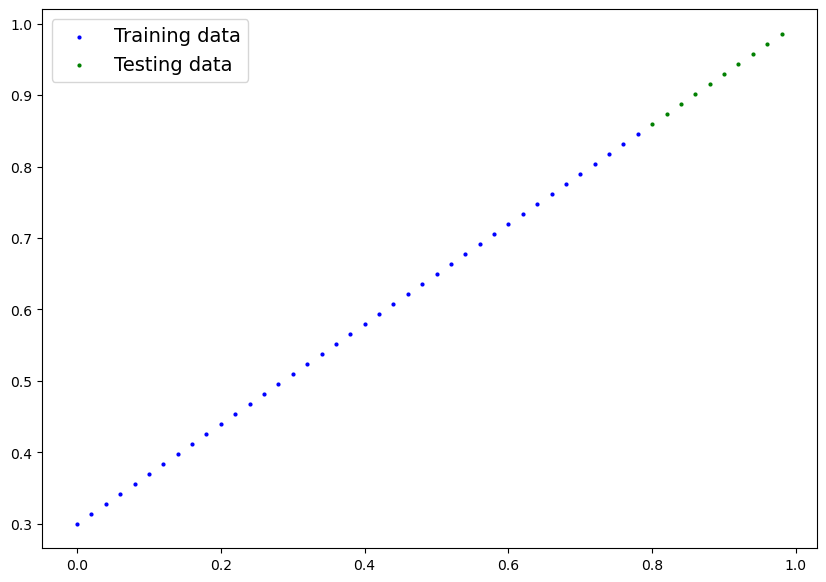

In [8]:
plot_predictions()

## 2. build model

Our first pytorch model

In [9]:
import torch
from torch import nn

In [10]:
# Create  Linear regression model class
class LinearRegressionModel(nn.Module): # almost everything in pytorch inherits from nn.Module
    def __init__(self):
        super().__init__() #Run the __init__ method of my parent class
        #Initialize model parameters
        self.weights = nn.Parameter(torch.randn(1, # Start with the random weight and try to adjust it to the ideal weight
                                                requires_grad=True, # can this parameter be updated via gradient descent?
                                                dtype=torch.float))
        self.bias = nn.Parameter(torch.randn(1, # Start with the random bias and try to adjust it to the ideal bias
                                             requires_grad=True, # can this parameter be updated via gradient descent?
                                             dtype=torch.float))
        
    # Forward method to define the computation in the model
    def forward(self,x: torch.Tensor) -> torch.Tensor: # x is the input data
        return self.weights * x + self.bias


### Checking the contents of out pytorch model

Now we have created a model lets see what's inside...

So we can check our model parameter or what's inside our model using `.parameters()`


In [11]:
import torch 
# Create the random seed 
torch.manual_seed(42)

#Create an instance of the model ( this is a subclass of nn.Module)

model_0 = LinearRegressionModel()

# check the parameters
list(model_0.parameters())

[Parameter containing:
 tensor([0.3367], requires_grad=True),
 Parameter containing:
 tensor([0.1288], requires_grad=True)]

In [12]:
# List named paramters

model_0.state_dict()


OrderedDict([('weights', tensor([0.3367])), ('bias', tensor([0.1288]))])

### Making prediction using `torch.inference_mode()`
To check our models predictive power, lets see how well it predicts y_test based on X_test

when we passs data through our model, its going to run it through the `forward()` method

In [13]:
X_test , y_test

(tensor([[0.8000],
         [0.8200],
         [0.8400],
         [0.8600],
         [0.8800],
         [0.9000],
         [0.9200],
         [0.9400],
         [0.9600],
         [0.9800]]),
 tensor([[0.8600],
         [0.8740],
         [0.8880],
         [0.9020],
         [0.9160],
         [0.9300],
         [0.9440],
         [0.9580],
         [0.9720],
         [0.9860]]))

In [14]:
y_pred = model_0(X_test)
y_pred

tensor([[0.3982],
        [0.4049],
        [0.4116],
        [0.4184],
        [0.4251],
        [0.4318],
        [0.4386],
        [0.4453],
        [0.4520],
        [0.4588]], grad_fn=<AddBackward0>)

As the name suggests, torch.inference_mode() is used when using a model for inference (making predictions).

torch.inference_mode() turns off a bunch of things (like gradient tracking, which is necessary for training but not for inference) to make forward-passes (data going through the forward() method) faster.

In [15]:
# Make prediction with models

with torch.inference_mode(): # Using the inference mode does not track the grads. because during inference we dont need grad. larger dataset many grads tracking thats not feasible
    y_pred = model_0(X_test)

# you can also do something with torch.no_grad(), however torch.inference_mode is preferred
with torch.no_grad():
    y_pred=model_0(X_test)

y_pred

tensor([[0.3982],
        [0.4049],
        [0.4116],
        [0.4184],
        [0.4251],
        [0.4318],
        [0.4386],
        [0.4453],
        [0.4520],
        [0.4588]])

In [16]:
y_test

tensor([[0.8600],
        [0.8740],
        [0.8880],
        [0.9020],
        [0.9160],
        [0.9300],
        [0.9440],
        [0.9580],
        [0.9720],
        [0.9860]])

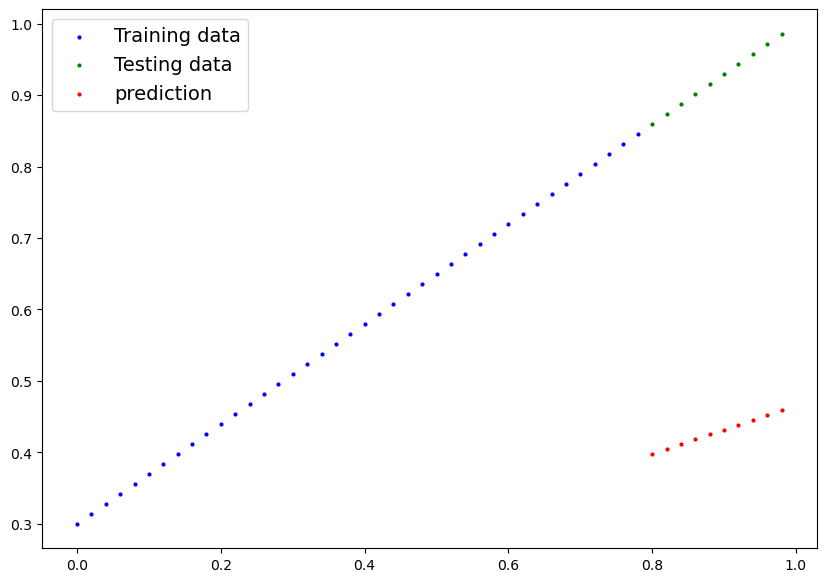

In [17]:
plot_predictions(predictions=y_pred)

## 3. Train a model

The whole idea of training is for a model to move from some unknown paramters (these may be random) to some known parameters.

Or in other words from a poor representaion of the data to a better representation of the data  

One way to measure how poor or how  wrong your models prediction are is to use a loss function.

Things we need to train:

**Loss fucntion** : A function to measure how wrong your models prediction are to the ideal outputs, lower is better

**Optimizers** : Takes into acount the loss of the model and adjust the models parameters (eg Weight & Bias in our case) to improve the lsos function.

And specifically for pytorch, we need:
* A training loop
* A testing loop



In [18]:
model_0.state_dict()

OrderedDict([('weights', tensor([0.3367])), ('bias', tensor([0.1288]))])

In [ ]:
# Setup a loss function
loss_fn= nn.L1Loss()  # MAE

#Setup an optimizer - stochastic gradient descent
optimizer = torch.optim.SGD(params=model_0.parameters(),
                            lr=0.01)
 


In [20]:
loss_fn

L1Loss()

### Building the training and testing loop in Pytorch
A couple of things we need in a training loop:  

0. Loop through the data and do..
1. Forward pass (Data moving through our models) to make prediction on data 
2. Calculate the loss (compare the frwd pass predictions to ground truth labels)
3. Optimizer zero grad
4. Loss backward - move backward through the network to calcualte the gradient of each parameter of the model wrt loss
5. Optimizer step - Use the optimizer to adjust our model parameter to try and improve loss

In [28]:
with torch.no_grad():
    print(list(model_0.parameters()))


[Parameter containing:
tensor([0.3367], requires_grad=True), Parameter containing:
tensor([0.1288], requires_grad=True)]


In [29]:
print(list(model_0.parameters()))

[Parameter containing:
tensor([0.3367], requires_grad=True), Parameter containing:
tensor([0.1288], requires_grad=True)]


In [47]:
torch.manual_seed(42)
# epoch is one loop through the data
epochs =100

for epoch in range(epochs):
    # set the model to training mode
    model_0.train() # Train mode in pytorch set all parameter that requires gradient

    # 1. forward pass
    y_pred=model_0(X_train)

    # 2. Calcualte the loss
    loss = loss_fn(y_pred,y_train)
    print(f"Loss : {loss}")

    # 3. Optimizer
    optimizer.zero_grad()

    # 4. Perform back propagation on the loss wrt parameters of the model
    loss.backward()

    # 5. Step the optimizer (perform gradient descent)
    # “Use the gradients to update the weights.”
    optimizer.step() # by default how the optimizers changes will accumulate through the loop so... we have to zero them above in the step 3 for the next iteration of the loop


    # testing
    model_0.eval() #Turn off gradient tracking
    


Loss : 0.02788739837706089
Loss : 0.02754882536828518
Loss : 0.027199819684028625
Loss : 0.026862185448408127
Loss : 0.02651461586356163
Loss : 0.026173178106546402
Loss : 0.025829419493675232
Loss : 0.02548416517674923
Loss : 0.025144213810563087
Loss : 0.02479521557688713
Loss : 0.024458957836031914
Loss : 0.024110013619065285
Loss : 0.02376994863152504
Loss : 0.02342480979859829
Loss : 0.023080935701727867
Loss : 0.022739607840776443
Loss : 0.022391926497220993
Loss : 0.022054409608244896
Loss : 0.02170540764927864
Loss : 0.021366719156503677
Loss : 0.021020207554101944
Loss : 0.020677709951996803
Loss : 0.02033500373363495
Loss : 0.01998869702219963
Loss : 0.019649803638458252
Loss : 0.019300809130072594
Loss : 0.018963487818837166
Loss : 0.01861560344696045
Loss : 0.018274478614330292
Loss : 0.017930403351783752
Loss : 0.01758546568453312
Loss : 0.017245199531316757
Loss : 0.016896454617381096
Loss : 0.01656000316143036
Loss : 0.016210997477173805
Loss : 0.01587124727666378
Loss :

In [48]:
model_0.state_dict()

OrderedDict([('weights', tensor([0.6990])), ('bias', tensor([0.3093]))])

In [51]:
with torch.inference_mode():
    y_pred_news= model_0(X_test)

In [33]:
model_0.state_dict()

OrderedDict([('weights', tensor([0.3445])), ('bias', tensor([0.1488]))])

In [40]:
weight , bias

(0.7, 0.3)

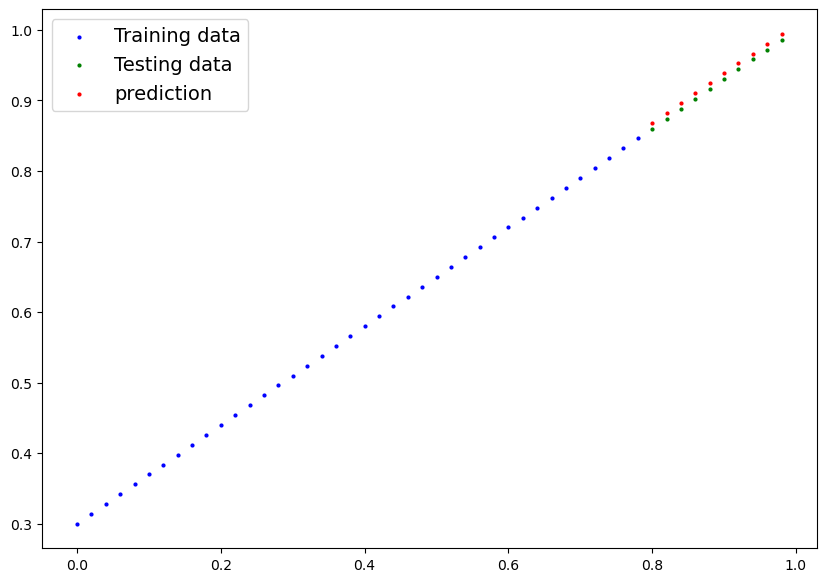

In [52]:
plot_predictions(predictions=y_pred_news)